![logo](../../../LogoLine_horizon_C3S.png)

<div class="alert alert-block alert-warning">
Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch
</div>

# Impact of El Niño Southern Oscillations on the atmospheric humidity profiles

Production date: 17-07-2024

Produced by: CNRS

## 🌍 Use case: Observing the variations of atmospheric humidity profiles during El Nino Southern Oscillations phases

## ❓ Quality assessment question:
 - __How much vary the humidity profiles measured by satellite during positive and negative ENSO phases in the deep tropics?__

The water vapour is the most significant greenhouse gases, contributing to about half of the planet's global greenhouse effect ([[1]](https://doi.org/10.1029/2010JD014287), [[2]](https://journals.ametsoc.org/view/journals/bams/78/2/1520-0477_1997_078_0197_eagmeb_2_0_co_2.xml)). As a result, it plays a important role in shaping the Earth's radiation budget. Moreover, the vertical distribution of humidity in the atmosphere both control and influence weather and climate processes, through the atmospheric water cycle : evaporation, condensation (to form clouds) and precipitation.

One of the primary drivers of climate variability is the El Niño Southern Oscillation or ENSO ([[3]](https://link.springer.com/chapter/10.1007/978-94-017-7499-4_4), [[4]](https://doi.org/10.1038/s41586-018-0252-6)).
The ENSO cycle has two distinct phases: positive (El Niño) and negative (La Niña). During the positive phase, El Niño, warmer-than-average sea surface temperatures occur in the central and eastern Pacific Ocean, leading to increased atmospheric convection and higher humidity levels. Conversely, the negative phase, La Niña, is characterized by cooler-than-average sea surface temperatures in the same regions, which suppresses convection and results in drier conditions.

```{figure} 9f7b5f18-3798-4553-9d7a-7fc57cc322b4.png
---
height: 300px
---
Schematic of El Nino / La Nina pattern of warming and colloing on the surface temperature. Taken from https://www.climate.gov/enso
```

Therefore, ENSO significantly impacts tropospheric humidity profiles (THP) by altering the spatial distribution and intensity of convection over the tropics. As a result, the tropical-averaged humidity profile is markedly influenced by both ENSO phases.

This analysis make use of the dataset __Tropospheric humidity proﬁles averaged monthly and zonally from
2006 to present derived from satellite observations__ [[described here]](https://cds.climate.copernicus.eu/datasets/satellite-humidity-profiles), which provides monthly and zonally averaged tropospheric specific humidity proﬁles (in g/kg), available on the Climate Data Store (CDS) of the Copernicus Climate Change Service.

This notebook illustrates the relationship between ENSO and humidity profiles. Additionally, the analysis aims to verify if the results align with previous studies [[6]](https://doi.org/10.1175/JCLI-D-21-0884.1) to ensure the quality of the satellite dataset that is used.


## 📢 Quality assessment statement 

```{admonition} These are the key outcomes of this assessment
:class: note

- The uncertainties in the humidity profiles are similar during both positive and negative ENSO conditions. The uncertainty is small in the lower troposphere (about 1%) and increases with altitude, reaching about 3% in the free troposphere.

- A significant increase (during positive ENSO) or decrease (during negative ENSO) in humidity is observed at all levels of the troposphere. The deviation from the mean becomes larger with altitude.

- The results are consistent with those reported in [[6]](https://doi.org/10.1175/JCLI-D-21-0884.1), confirming the reliability and accuracy of the satellite dataset utilized in this analysis.
```


## 📋 Methodology

(satellite_satellite-humidity-profiles_validation_q01:method-section-1)=
### Description of the approach
The ENSO oscillation primarily affects humidity and convection during the boreal winter season, which is December-January-February (DJF). Therefore, this use case focuses on humidity profiles measured during that season. We examine two specific periods representing positive ('+') and negative ('-') ENSO phases.

Climatological profiles are then computed for the deep tropics, restricted to 10°S-10°N. To quantify the deviation from neutral conditions, the ratio between the humidity profile of a given ENSO phase and the climatological profile is defined as:

$$
\begin{align}
R^+(z) &= \frac{q(z, t = DJF^+)}{\overline{q(z)}}\\
R^-(z) &= \frac{q(z, t = DJF^-)}{\overline{q(z)}}
\end{align}
$$

where q(z, t) is the specific humidity profile at time $t$ (in g/kg), and $\overline{q(z)}$ is the climatological average of specific humidity profiles for boreal winter. $DJF^+$ stands for positive '+' ENSO phase and $DJF^-$ stands for negative '-' ENSO phases.

The THP data record provides two different types of uncertainties: the _measurement error_ which is the uncertainty of the individual profiles propagated to the monthly mean, and the _sampling error_ which is the uncertainty coming from under-sampling the atmospheric variability. These two errors or uncertainties are independent and they are combined in order to have a more complete uncertainty value :

$$\text{total uncertainty} = \sqrt{(\text{measurement error})^2 + (\text{sampling error})^2}$$

### Method
The analysis comprises the following steps:

__1. [](satellite_satellite-humidity-profiles_validation_q01:data-section-1)__
 - Import the relevant packages.
 - Define the parameters of the analysis and set the dataset requests

__2. [](satellite_satellite-humidity-profiles_validation_q01:data-section-2)__
 - Download the variables of interest: __Tropospheric humidity proﬁles averaged monthly and zonally from 2006 to present derived from satellite observations__ [[described here]](https://cds.climate.copernicus.eu/datasets/satellite-humidity-profiles)
 - Only December-January-February seasons are considered : DJF of 2015-2016 illustrates positive ENSO conditions, and DJF of 2010-2011 illustrates negative ENSO conditions

__3. [](satellite_satellite-humidity-profiles_validation_q01:Analysis-section-1)__
 - The general climatology of zonally averaged tropospheric humidity profiles is described as well as it temporal evolution over 2006-2025.
 
__4. [](satellite_satellite-humidity-profiles_validation_q01:Plot-and-results)__
 - The climatological humidity profile for the Deep Tropics (10°N-10°S) during the boreal winter season (DJF) is computed and visualized. 
 - The ratio of the humidity profiles for the two case studies to the climatological mean is calculated and displayed.
 - The results are compared with proper references.

## 📈 Analysis and results

(satellite_satellite-humidity-profiles_validation_q01:data-section-1)=
### Choose the parameters to use and setup code

#### Import packages

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import numpy as np
from c3s_eqc_automatic_quality_control import download

plt.style.use("seaborn-v0_8-notebook")

import os
os.environ["CDSAPI_RC"] = os.path.expanduser("~/helene_brogniez/.cdsapirc")

#### Define parameters

This use case is developed for 3-month periods for the boreal winter (December-January-February) and for the tropical belt, restricted to 10$^\circ$S-10$^\circ$N.

In [2]:
# Time
start = "2007-01"
stop = "2024-02"

# Region:
lat_min = -10
lat_max = 10
lon_min = -180
lon_max = 180

#### Set the data request

Only one dataset is requested :
- Tropospheric Humidity profiles (THP)

In [3]:
dataset = "satellite-humidity-profiles"

request = {
    "variable": "all",
    "product_type": "radio_occultation_data",
    "year": [
        "2006", "2007", "2008",
        "2009", "2010", "2011",
        "2012", "2013", "2014",
        "2015", "2016", "2017",
        "2018", "2019", "2020",
        "2021", "2022", "2023",
        "2024", "2025"
    ],
    "month": ["01", "02", "12"]
}

(satellite_satellite-humidity-profiles_validation_q01:data-section-2)=
### Download the dataset and re-organize the dataset

The dataset is now downloaded.

In [4]:
ds_THP = download.download_and_transform(
    dataset,
    request,
)

100%|██████████| 1/1 [00:00<00:00,  5.42it/s]
/data/common/miniforge3/envs/wp5/lib/python3.12/site-packages/earthkit/data/readers/netcdf/fieldlist.py:202: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.open_mfdataset(


The Tropospheric Humidity Profiles (THP) are obtained from radio-occultation measurements, provided by EUMETSAT, at 5° resolution. The THP are retrieved under all weather conditions using time-delayed radio signals from the GNSS constellation of satellites (Global Navigation Satellite System) and the atmospheric properties are derived from these measurements [[5]](https://amt.copernicus.org/articles/13/3081/2020/).

The geophysical information is obtained along nearly horizontal paths through the atmosphere, when a given satellite-based instrument receives a radio signal from a GNSS satellite. This means that individual profiles are obtained only at locations of the Earth when the occultation is possible : those individual profiles are aggregated in latitude bands only and at the monthly scale to get a climatology.

The longitude coordinate is thus discarded in the dataset because if does not change in the file.

In [6]:
ds_THP = (
    ds_THP.squeeze(drop=True)
    .set_coords([var for var, da in ds_THP.data_vars.items() if set(da.dims) == {"time"}])
    .sel(alt=slice(0,12000))
    .compute()
)

(satellite_satellite-humidity-profiles_validation_q01:Analysis-section-1)=
### Overview of the geophysical variables of interest

#### **Climatology**

The diagram below shows the averaged vertical distribution of THP, over the average DJF season computed for the full period 2006-2025.

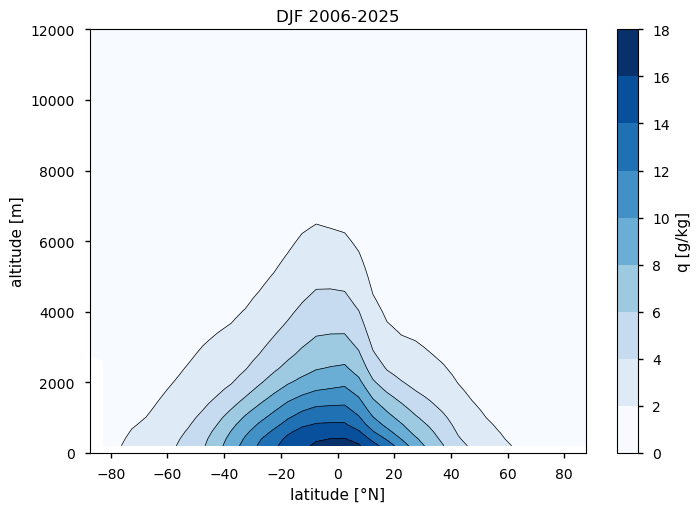

In [7]:
plot_kwargs = {"x": "latitude", "y": "alt", "levels":11}

ds_clim = ds_THP.mean('time', keep_attrs=True)['Q']

# plot the density contour
contour = ds_clim.plot.contourf(cmap="Blues",  **plot_kwargs, add_colorbar=False)
ds_clim.plot.contour(colors="k", linewidths=0.5, **plot_kwargs)

plt.title("DJF 2006-2025")
plt.ylabel('altitude [m]')
plt.xlabel('latitude [°N]')
plt.colorbar(contour, label='q [g/kg]')

plt.show()

*Figure 1: Zonally averaged specific humidity q (in g/kg) as a function of the altitude (m) and the latitude for the period December-January-February 2006-2025*

We can see that the highest values of humidity is close to the surface, and around the equator. The amplitude drops quickly with altitude with a quasi-exponential decrease.

#### **Time evolution**
We can further look at the temporal evolution of humidity over the available period 2006-2025, with respect to the climatological average :

$$
\Delta q(z) = q(z,t) - \overline{q(z,t)}
$$

Two altitudes are chosen, $z_1$ = 2 km and $z_2$ = 5km, to have an insight of the vertical consistency in the time evolution of $q(t)$.

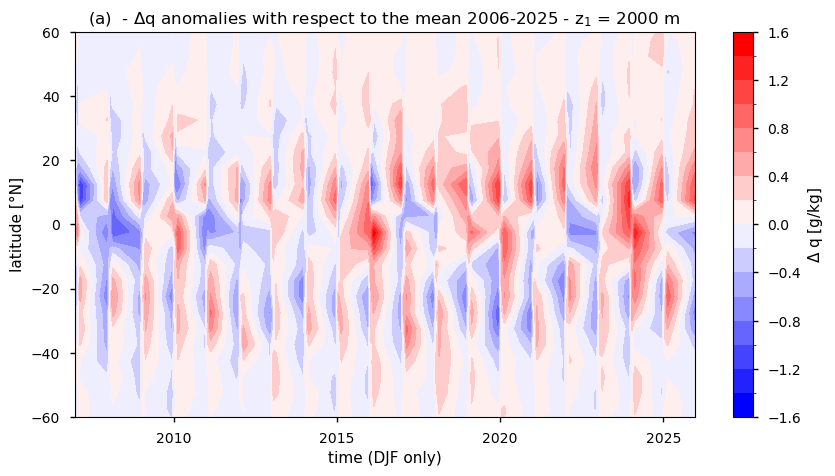

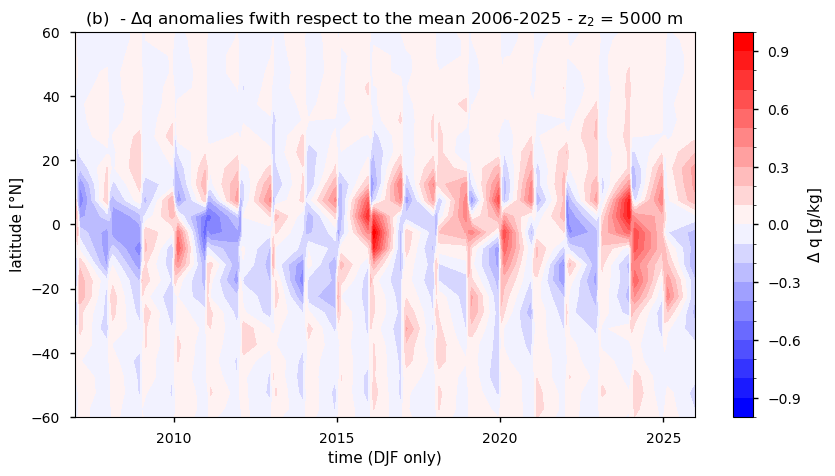

In [22]:
## define the altitudes of interest z1 and z2
z1 = 2000.
z2 = 5000.
    
## extraction of the altitudes of interest Z1 and z2 in the dataset
ds_THP_z1 =ds_THP.Q.sel(alt=z1, method='nearest')
ds_THP_z2 =ds_THP.Q.sel(alt=z2, method='nearest')

## computation of the anomaly at z1 and z2
ds_THP_z1_anomaly = ds_THP_z1 - ds_THP_z1.mean('time', keep_attrs=True)
ds_THP_z2_anomaly = ds_THP_z2 - ds_THP_z2.mean('time', keep_attrs=True)

### for z1=2 km
## and plot the result
fig, ax = plt.subplots(figsize=(10, 5))
plot_kwargs = {"y": "latitude", "x": "time", "levels":21}
contour = ds_THP_z1_anomaly.plot.contourf(cmap="bwr",  **plot_kwargs, add_colorbar=False)
plt.title("(a)  - $\\Delta$q anomalies with respect to the mean 2006-2025 - z$_1$ = 2000 m")
plt.ylim(-60,60)
plt.colorbar(contour, label="$\\Delta$ q [g/kg]")
plt.xlabel('time (DJF only)')
plt.ylabel('latitude [°N]')
plt.show()

### for z2=5 km
## and plot the result
fig, ax = plt.subplots(figsize=(10, 5))
plot_kwargs = {"y": "latitude", "x": "time", "levels":21}
contour = ds_THP_z2_anomaly.plot.contourf(cmap="bwr",  **plot_kwargs, add_colorbar=False)
plt.title("(b)  - $\\Delta$q anomalies fwith respect to the mean 2006-2025 - z$_2$ = 5000 m")
plt.ylim(-60,60)
plt.colorbar(contour, label="$\\Delta$ q [g/kg]")
plt.xlabel('time (DJF only)')
plt.ylabel('latitude [°N]')

plt.show()

*Figure 2: Time evolution of the anomaly of the zonally averaged specific humidity $\Delta$q as a function of the latitude. The time evolution concerns only December-January-February periods. (a) For z$_1$ = 2000 m, (b) for z$_2$ = 5000 m.*

The patterns of global scale anomalies on Figure 2 reveal an alternance of dryer and moister lower troposphere (at z = 2km), the anomalies being more pronounced in the tropics (20°S/20°N) than at higher latitudes.

These anomalies correlate with ENSO index, such as the NINO3.4 index shown below:

```{figure} 698d89ba-95cc-4010-8bf8-e9b5fc55b3d3.png
---
height: 300px
---
NINO3.4 index as sea surface temperature (SST) anomalies averaged over the region 5°North-5°South;170-120°West. Calculated from the Monthly Extended Reconstructed SST V5 (ERSST, at NOAA/CPC). Taken from https://psl.noaa.gov/enso/dashboard.html
```

(satellite_satellite-humidity-profiles_validation_q01:Plot-and-results)=
### Plot and description of the results

#### Climatological humidity profile in the Deep Tropics (10°N/10°S)

Before comparing positive and negative phases of ENSO in terms of atmospheric profiles, the average profile of Deep Tropic area is compared to the global profile.

In [24]:
## latitude limited to 10°N - 10°S
ds_deep_tropics = ds_THP.sel(latitude=slice(lat_min,lat_max))
ds_deep_tropics_mean = ds_deep_tropics.mean(['latitude', 'time'])

## global average
ds_global = ds_THP.mean(['latitude', 'time'])

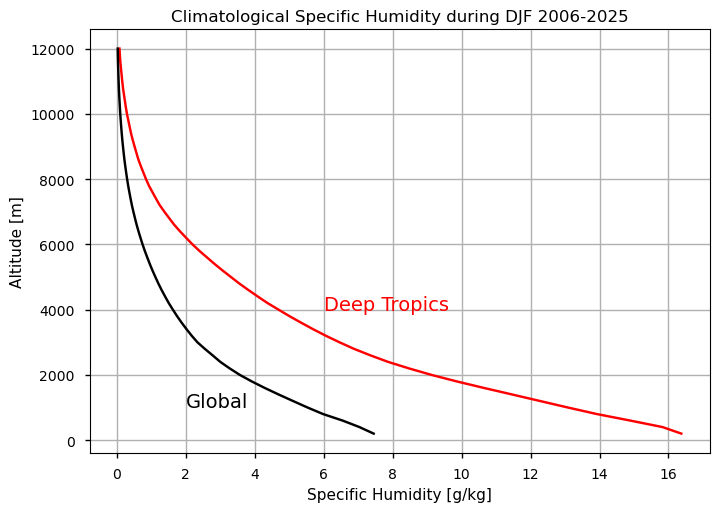

In [25]:
line1 = plt.plot(ds_deep_tropics_mean["Q"], ds_deep_tropics_mean["alt"], c='r')
line2 = plt.plot(ds_global["Q"],ds_global["alt"], c="k")

plt.xlabel('Specific Humidity [g/kg]')
plt.ylabel('Altitude [m]')
plt.title('Climatological Specific Humidity during DJF 2006-2025')
plt.grid(True)
plt.text(6,4000,'Deep Tropics', fontsize=14, c='r')
plt.text(2,1000,'Global', fontsize=14, c='k')

plt.show()

*Figure 3: Averaged tropospheric humidity profiles at the global scale (in black) and in the deep tropics 10°N-10°S (in red).*

As expected, from the Figure 1, the THP of the Deep Tropics is moister than the global average.

#### Tropospheric humidity profiles for positive and negative ENSO conditions

From the NINO3.4 figure above, two DJF periods are selected to represent positive and negative ENSO conditions:
- DJF 2010-2011 : is selected as representative of a negative ENSO phase ($DJF^-$)
- DJF 2015-2016 : is selected as representative of a positive ENSO phase ($DJF^+$)

From Figure 2, and as introduced at the beginning of this Use Case, the positive DJF 2015-2016 should be moister than usual, while the DJF 2010-2011 should be drier than usual. 

We finally compute the ratios $R^+$ and $R^-$ presented in the section '[](satellite_satellite-humidity-profiles_validation_q01:method-section-1)' in the __Methodology__ Chapter in order to quantify the deviation of the selected DJF seasons to neutral conditions, the latter being defined as the climatology.

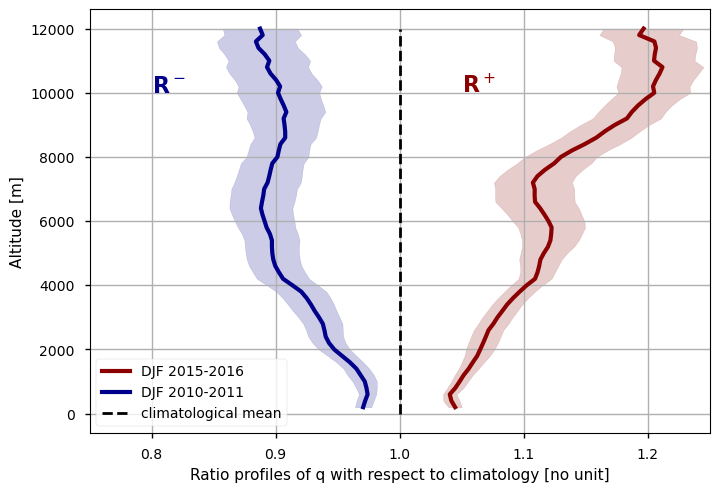

In [28]:
# Case studies and associated colors
colors = dict()
colors['2015'] = 'darkred'
colors['2010'] = 'darkblue'

# Case studies
years = list(colors.keys())

for yy in years :
    t_slice = slice(f'{yy}-12-01', f'{int(yy)+1}-02-28')
    data_selected = ds_deep_tropics.sel(time=t_slice)
    data = data_selected.mean(['latitude', 'time'])
    data['error'] = np.sqrt( (data_selected['Q_samperr']**2  + \
                              data_selected['Q_obssig']**2).mean(['latitude', 'time']) ) 

    plt.fill_betweenx( data["alt"],
                       (data["Q"] - data["error"]) / ds_deep_tropics_mean["Q"], 
                       (data["Q"] + data["error"]) / ds_deep_tropics_mean["Q"], 
                       color=colors[yy], alpha=0.2)
    plt.plot(data["Q"] / ds_deep_tropics_mean["Q"],
             data["alt"],
             c=colors[yy], lw=3, label=f'DJF {yy}-{int(yy)+1}')


plt.plot([1,1], [0,12000], color='k', linestyle='--', linewidth=2, label='climatological mean')

plt.legend(loc='lower left')

plt.xlabel('Ratio profiles of q with respect to climatology [no unit]')
plt.ylabel('Altitude [m]')
plt.grid(True)
plt.xlim([0.75,1.25])
plt.text(0.8,10000,'R$^-$', fontsize=16, c='darkblue', fontweight='bold')
plt.text(1.05,10000,'R$^+$', fontsize=16, c='darkred', fontweight='bold')

plt.show()

*Figure 4: Ratios of the specific humidity profile over the climatological humidity profile from the surface up to 12 km during two main ENSO events selected over the 2006-2025. The red curve represent the positive ENSO conditions during DJF 2015-2016 (R$^+$). The blue line represent the negative ENSO condition during DJF 2010-2011  (R$^-$). The shaded area represent the average uncertainty of each profile.*

This figure 4 shows the humidity profiles during positive and negative ENSO events. During the positive ENSO event of DJF 2015-2016, the troposphere is significantly wetter than under neutral conditions, with deviations ranging from 5% to 20%, this deviation increasing with altitude. In contrast, during the negative ENSO event of DJF 2010-2011, the troposphere is significantly drier than neutral conditions, with deviations ranging from 3% to 10%, also increasing with altitude.

The uncertainties for the two profiles are similar. In the lower troposphere, the uncertainty is relatively small, approximately 1%. However, as altitude increases, the uncertainty also increases, reaching about 3% in the free troposphere. This gradient in uncertainty highlights the greater variability and measurement challenges at higher altitudes compared to the more stable conditions near the surface.

Those results are consistent with the literature, for instance the findings of [[6]](https://doi.org/10.1175/JCLI-D-21-0884.1).

## ℹ️ If you want to know more
### Key resources
Some key resources and further reading were linked throughout this assessment.

The CDS catalogue entry for the data used is:
- Tropospheric humidity proﬁles averaged monthly and zonally from 2006 to present derived from satellite observations:
https://cds.climate.copernicus.eu/datasets/satellite-humidity-profiles

Code libraries used:
- [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`, prepared by [B-Open](https://www.bopen.eu/)

And some resources on El Nino : 
- https://www.climate.gov/enso

- https://wmo.int/topics/el-nino-la-nina

### Reference/Useful material

[[1]](https://doi.org/10.1029/2010JD014287) Schmidt, G. A., R. A. Ruedy, R. L. Miller, and A. A. Lacis (2010), Attribution of the present-day total greenhouse eﬀect,J. Geophys. Res.,115, D20106, doi:10.1029/2010JD014287.

[[2]](https://journals.ametsoc.org/view/journals/bams/78/2/1520-0477_1997_078_0197_eagmeb_2_0_co_2.xml) Kiehl J. T. and K. Trenberth (1997), Earth's Annual Global Mean Energy Budget, Bull. Am. Meteorol. Soc., 78, 197-208, https://doi.org/10.1175/1520-0477%281997%29078<0197:EAGMEB>2.0.CO;2

[[3]](https://link.springer.com/chapter/10.1007/978-94-017-7499-4_4) Wang, C., Deser, C., Yu, JY., DiNezio, P., Clement, A. (2017), El Niño and Southern Oscillation (ENSO): A Review. In: Glynn, P., Manzello, D., Enochs, I. (eds) Coral Reefs of the Eastern Tropical Pacific. Coral Reefs of the World, vol 8. Springer, Dordrecht. https://doi.org/10.1007/978-94-017-7499-4_4

[[4]](https://doi.org/10.1038/s41586-018-0252-6) Timmermann, A., An, SI., Kug, JS. et al (2018) El Niño–Southern Oscillation complexity. Nature 559, 535–545, https://doi.org/10.1038/s41586-018-0252-6

[[5]](https://amt.copernicus.org/articles/13/3081/2020/) Gleisner, H., Lauritsen, K. B., Nielsen, J. K., and Syndergaard, S., Evaluation of the 15 year ROM SAF monthly mean GPS radio occultation climate data record, Atmos. Meas. Tech., 13, 3081-3098, doi:10.5194/amt-13-3081-2020.

[[6]](https://doi.org/10.1175/JCLI-D-21-0884.1) Johnston, B. R., W. J. Randel, and J. J. Braun, 2022: Interannual Variability of Tropospheric Moisture and Temperature and Relationships to ENSO Using COSMIC-1 GNSS-RO Retrievals. J. Climate, 35, 7109–7125. 
